# DATA DOWNLOAD

In [1]:
# Requirements:
!pip install arch
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download Apple data
# ----------------------------
ticker = "GLD"
start_date = "2020-01-01"
end_date   = "2026-03-01"


df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.3 MB/s eta 0:00:00


## Time Series Plot


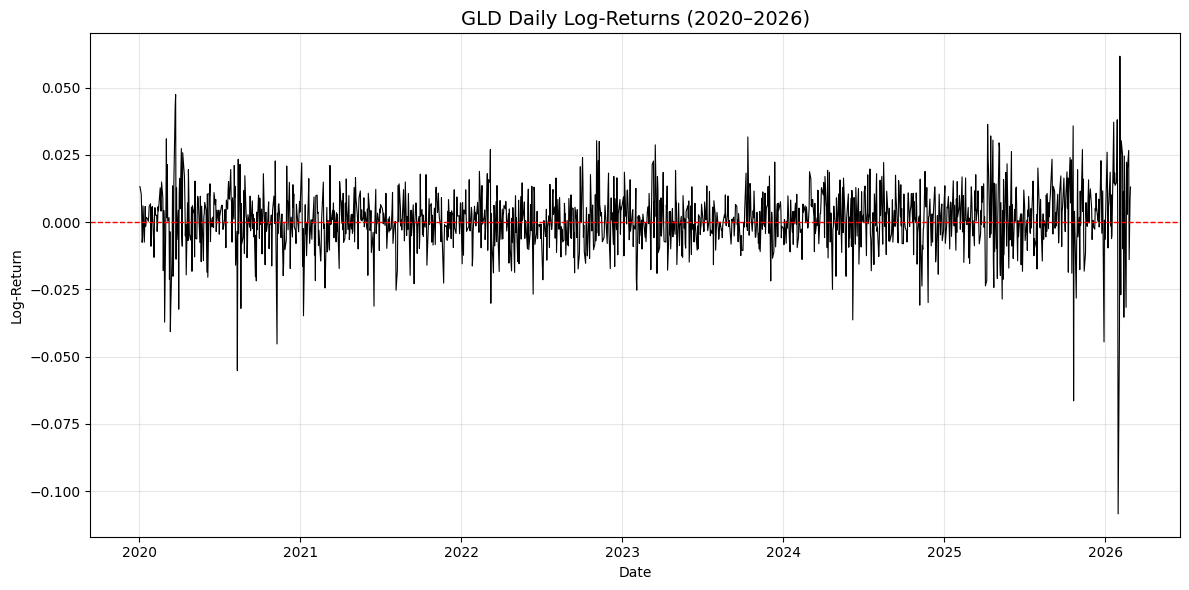

In [2]:
# ----------------------------
# Plot log-returns
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(log_ret.index, log_ret, color="black", linewidth=0.8)

plt.axhline(0, color="red", linestyle="--", linewidth=1)

plt.title("GLD Daily Log-Returns (2020–2026)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Log-Return")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Volatility Estimate with GARCH



In [3]:
import pandas as pd
from arch import arch_model

# Initialize variables for tracking the best model
best_model = None
best_bic = np.inf
best_order = (0, 0,0, 0)  # (AR order, GARCH p, GARCH q)

# Search over combinations of AR(p), GARCH(p), and GARCH(q) parameters
for p in range(7):  # AR order
    for garch_p in range(1, 3):  # GARCH p (exclude 0 for GARCH)
        for garch_q in range(0, 3):
          for garch_o in range(0, 1):
            try:
                # Fit AR(p) + GARCH(p, q) model
                model = arch_model(100*log_ret, mean='AR', lags=p, vol='Garch', p=garch_p,o=garch_o, q=garch_q, dist = 't')
                result = model.fit(disp="off")

                # Track the best model based on BIC
                if result.bic < best_bic:
                    best_bic = result.bic
                    best_model = result
                    best_order = (p, garch_p, garch_o, garch_q)
            except Exception as e:
                # Handle any errors during model fitting
                print(f"Error with AR({p}) + GARCH({garch_p}, {garch_o}, {garch_q}): {e}")

# Display the best model summary
print(f"Best AR order: {best_order[0]}, Best GARCH orders: ({best_order[1]},{best_order[2]} {best_order[3]})")
print(f"Best BIC: {best_bic}")



Best AR order: 0, Best GARCH orders: (1,0 1)
Best BIC: 4382.459758428057


## Fitting the Best Model



In [4]:
from arch import arch_model

# Unpack best orders from your search
best_ar, best_p, best_o, best_q = best_order

# Mean specification: if AR order is 0, use Constant (cleaner than mean='AR', lags=0)
if best_ar == 0:
    mean_spec = "Constant"
    lags_spec = None
else:
    mean_spec = "AR"
    lags_spec = best_ar

# Fit the best model
best_am = arch_model(
    100*log_ret,
    mean=mean_spec,
    lags=lags_spec,
    vol="GARCH",
    p=best_p,
    o=best_o,
    q=best_q,
    dist="t"
)

best_res = best_am.fit(disp="off")

print("=====================================")
print("Best fitted model (by BIC)")
print("=====================================")
print(f"Mean: {mean_spec}" + (f" with lags={best_ar}" if best_ar > 0 else ""))
print(f"Vol : {'GJR-GARCH' if best_o>0 else 'GARCH'}({best_p},{best_o},{best_q})")
print("Dist: t")
print(f"BIC : {best_res.bic:.3f}")
print("=====================================\n")

print(best_res.summary())

Best fitted model (by BIC)
Mean: Constant
Vol : GARCH(1,0,1)
Dist: t
BIC : 4382.460

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2172.87
Distribution:      Standardized Student's t   AIC:                           4355.74
Method:                  Maximum Likelihood   BIC:                           4382.46
                                              No. Observations:                 1546
Date:                      Sun, Mar 08 2026   Df Residuals:                     1545
Time:                              20:49:57   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.



Head of conditional volatility:
Date
2020-01-03    0.929284
2020-01-06    0.970574
2020-01-07    0.976611
2020-01-08    0.942608
2020-01-09    0.942538
Name: cond_vol, dtype: float64

Head of standardized residuals:
Date
2020-01-03    1.327386
2020-01-06    0.987951
2020-01-07    0.315515
2020-01-08   -0.888585
2020-01-09   -0.691087
Name: std_resid, dtype: float64


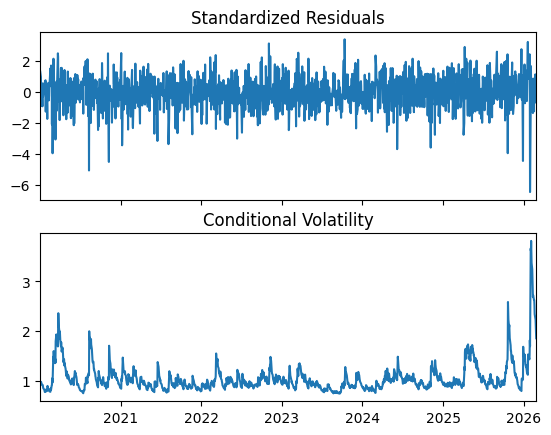

In [5]:
cond_vol = best_res.conditional_volatility
std_resid = best_res.std_resid

print("\nHead of conditional volatility:")
print(cond_vol.head())

print("\nHead of standardized residuals:")
print(std_resid.head())

best_res.plot()
plt.show()

## Compare Distributions of Returns and Residuals

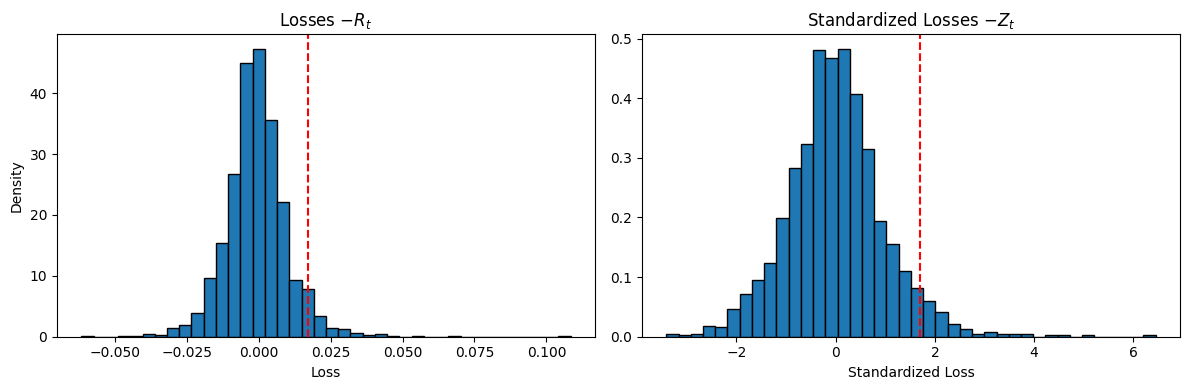

In [6]:
# Define losses (negative returns)
losses = -log_ret.dropna()

# Standardized losses (negative standardized residuals)
std_losses = -std_resid.loc[losses.index]

# 95% quantiles (right tail = extreme losses)
q95_loss = np.quantile(losses, 0.95)
q95_std  = np.quantile(std_losses, 0.95)

# Side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Raw losses
axes[0].hist(losses, bins=40, density=True, edgecolor='black')
axes[0].axvline(q95_loss, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title("Losses $-R_t$")
axes[0].set_xlabel("Loss")
axes[0].set_ylabel("Density")

# Standardized losses
axes[1].hist(std_losses, bins=40, density=True, edgecolor='black')
axes[1].axvline(q95_std, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title("Standardized Losses $-Z_t$")
axes[1].set_xlabel("Standardized Loss")

plt.tight_layout()
plt.show()

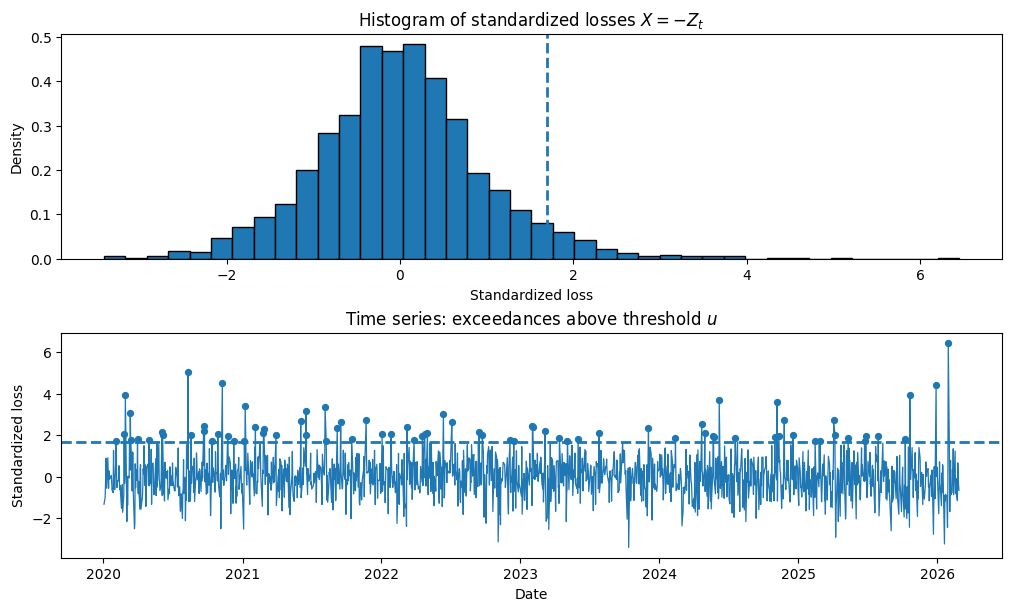

Saved: pot_threshold.png


In [7]:
# Standardized losses (right tail = extreme losses)
x = -std_resid.dropna()

# 95% threshold
u = np.quantile(x, 0.95)

fig, ax = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

# --- (1) Histogram ---
ax[0].hist(x, bins=40, density=True, edgecolor='black')
ax[0].axvline(u, linestyle='--', linewidth=2)
ax[0].set_title(r'Histogram of standardized losses $X=-Z_t$')
ax[0].set_xlabel('Standardized loss')
ax[0].set_ylabel('Density')

# --- (2) Time series ---
ax[1].plot(x.index, x.values, linewidth=0.9)
ax[1].scatter(x.index[x > u], x[x > u], s=18)
ax[1].axhline(u, linestyle='--', linewidth=2)
ax[1].set_title(r'Time series: exceedances above threshold $u$')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Standardized loss')

# Save
outpath = "pot_threshold.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

## Fitting the Pareto

Estimated shape xi = 0.2604
Estimated scale sigma = 0.5132


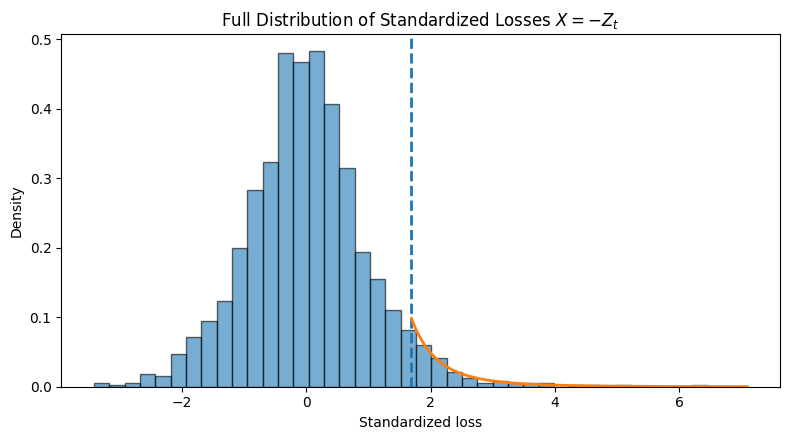

In [8]:
from scipy.stats import genpareto

# Choose threshold (95% quantile)
u = np.quantile(x, 0.95)
exceed_idx = x > u
excesses = (x[exceed_idx] - u).dropna().values  # Y = X - u

if len(excesses) < 10:
    raise RuntimeError(f"Too few exceedances ({len(excesses)}) to fit a GPD. Consider lowering threshold.")

# Fit GPD to excesses with loc fixed at 0 (we model Y >= 0)
# SciPy parameterization: c = shape (xi), scale = scale (beta)
from scipy.stats import genpareto

# Choose threshold (95% quantile)
u = np.quantile(x, 0.95)
exceed_idx = x > u
excesses = (x[exceed_idx] - u).dropna().values  # Y = X - u

if len(excesses) < 10:
    raise RuntimeError(f"Too few exceedances ({len(excesses)}) to fit a GPD. Consider lowering threshold.")

# Fit GPD to excesses with loc fixed at 0 (we model Y >= 0)
# SciPy parameterization: c = shape (xi), scale = scale (beta)
c_hat, loc_hat, scale_hat = genpareto.fit(excesses, floc=0)

print(f"Estimated shape xi = {c_hat:.4f}")
print(f"Estimated scale sigma = {scale_hat:.4f}")

# Create full histogram
fig, ax = plt.subplots(figsize=(8,4.5))

ax.hist(x, bins=40, density=True, edgecolor='black', alpha=0.6)

# Threshold line
ax.axvline(u, linestyle='--', linewidth=2)

# Create grid for tail (only beyond u)
x_tail = np.linspace(u, x.max()*1.1, 200)

# Convert to excess scale
y_tail = x_tail - u

# Compute GPD density and adjust by tail probability
tail_prob = len(excesses) / len(x)
gpd_density = genpareto.pdf(y_tail, c_hat, loc=0, scale=scale_hat)

# Scale density to match original distribution
ax.plot(x_tail, tail_prob * gpd_density, linewidth=2)

ax.set_title(r'Full Distribution of Standardized Losses $X=-Z_t$')
ax.set_xlabel('Standardized loss')
ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig("pot_full_with_gpd.png", dpi=300)
plt.show()

# GPD Density Over Extremes Only

Estimated shape xi = 0.2604
Estimated scale sigma = 0.5132
Threshold u (95% quantile) = 1.6915
Number of exceedances = 78 (5.0% of data)


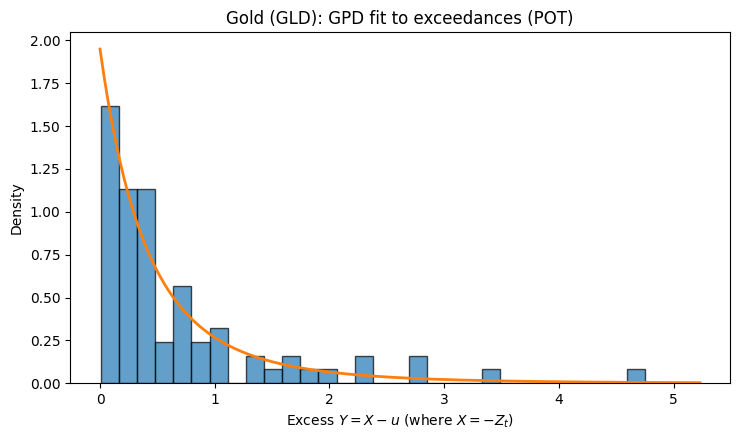

In [15]:
# x = standardized losses (right tail = extreme losses) e.g. x = (-std_resid.dropna())
u = np.quantile(x, 0.95)

excesses = (x[x > u] - u).dropna().values
c_hat, loc_hat, scale_hat = genpareto.fit(excesses, floc=0)

print(f"Estimated shape xi = {c_hat:.4f}")
print(f"Estimated scale sigma = {scale_hat:.4f}")
print(f"Threshold u (95% quantile) = {u:.4f}")
print(f"Number of exceedances = {len(excesses)} ({len(excesses)/len(x):.1%} of data)")

# Plot exceedances histogram + fitted GPD density
y_grid = np.linspace(0, excesses.max()*1.1, 300)
pdf = genpareto.pdf(y_grid, c_hat, loc=0, scale=scale_hat)

plt.figure(figsize=(7.5, 4.5))
plt.hist(excesses, bins=30, density=True, edgecolor='black', alpha=0.7)
plt.plot(y_grid, pdf, lw=2)
plt.title("Gold (GLD): GPD fit to exceedances (POT)")
plt.xlabel(r"Excess $Y = X-u$ (where $X=-Z_t$)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("gpd_exceedances_fit.png", dpi=300, bbox_inches="tight")
plt.show()

## VaR and ES for Standardized Losses

In [11]:
import numpy as np
from scipy.stats import genpareto

# -----------------------------
# USER INPUT
# -----------------------------
alpha = 0.99        # desired VaR level
q_u   = 0.95        # threshold quantile

# -----------------------------
# Data: standardized losses
# -----------------------------
x = (-std_resid.dropna())

# -----------------------------
# Threshold and exceedances
# -----------------------------
u = np.quantile(x, q_u)
excesses = (x[x > u] - u).values
p_u = len(excesses) / len(x)

if len(excesses) < 10:
    raise RuntimeError("Too few exceedances. Try lowering threshold.")

# -----------------------------
# Fit GPD
# -----------------------------
xi_hat, _, sigma_hat = genpareto.fit(excesses, floc=0)

print(f"Threshold quantile: {q_u}")
print(f"Threshold u: {u:.4f}")
print(f"Estimated xi: {xi_hat:.4f}")
print(f"Estimated sigma: {sigma_hat:.4f}")
print(f"Exceedance probability p_u: {p_u:.4f}")

# -----------------------------
# EVT VaR (standardized losses)
# -----------------------------
if alpha <= 1 - p_u:
    raise ValueError("Alpha must be in the tail beyond threshold.")

if abs(xi_hat) < 1e-8:
    VaR_Z = u + sigma_hat * np.log(p_u / (1 - alpha))
else:
    VaR_Z = u + (sigma_hat / xi_hat) * (
        (( (1 - alpha) / p_u ) ** (-xi_hat)) - 1
    )

print(f"\nEVT VaR_Z({alpha}) = {VaR_Z:.4f}")

if xi_hat < 1:
    ES_Z = (VaR_Z + sigma_hat - xi_hat * u) / (1 - xi_hat)
    print(f"EVT ES_Z({alpha}) = {ES_Z:.4f}")
else:
    print("ES is infinite (xi >= 1)")

Threshold quantile: 0.95
Threshold u: 1.6915
Estimated xi: 0.2604
Estimated sigma: 0.5132
Exceedance probability p_u: 0.0505

EVT VaR_Z(0.99) = 2.7246
EVT ES_Z(0.99) = 3.7823


## VaR and ES for Losses

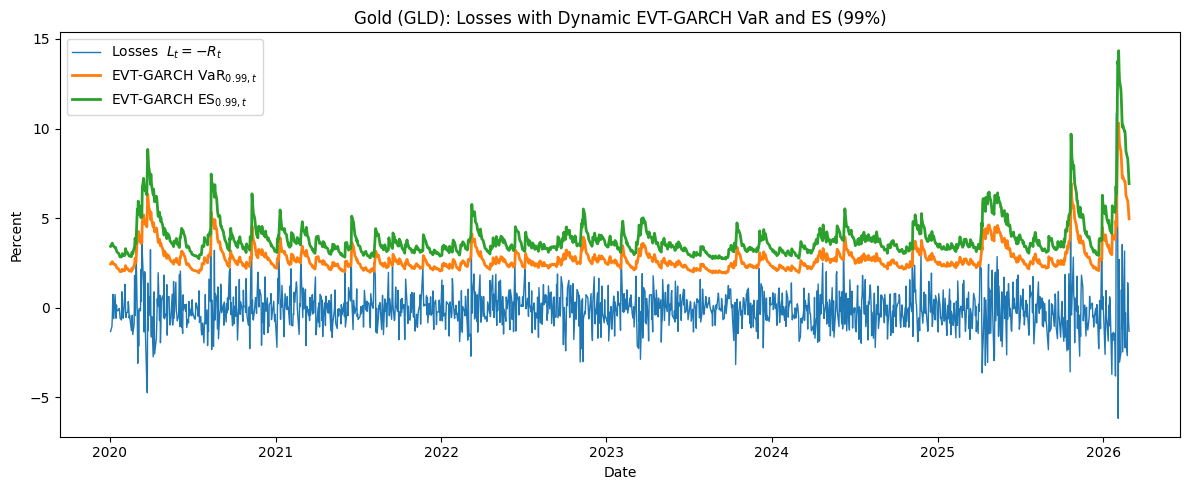

Saved: gold_evt_var_es_timeseries.png


In [12]:
# --------------------------
# Series from fitted GARCH
# --------------------------
cond_vol = best_res.conditional_volatility.dropna()  # in percent units (since you fit 100*log_ret)

# mean parameter name can differ; handle safely
mu = 0.0
for key in ["mu", "Const", "const"]:
    if key in best_res.params.index:
        mu = float(best_res.params[key])
        break

# --------------------------
# Actual losses series (percent)
# --------------------------
loss = -(100 * log_ret).dropna()  # in percent, aligned with model scale

# Align indices
idx = loss.index.intersection(cond_vol.index)
loss = loss.loc[idx]
cond_vol = cond_vol.loc[idx]

# --------------------------
# Dynamic EVT VaR/ES for losses
# --------------------------
VaR_L = -mu + cond_vol * VaR_Z
ES_L  = -mu + cond_vol * ES_Z

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(12,5))
plt.plot(loss.index, loss.values, linewidth=1, label="Losses  $L_t=-R_t$")
plt.plot(VaR_L.index, VaR_L.values, linewidth=2, label=r"EVT-GARCH VaR$_{0.99,t}$")
plt.plot(ES_L.index, ES_L.values, linewidth=2, label=r"EVT-GARCH ES$_{0.99,t}$")

plt.title("Gold (GLD): Losses with Dynamic EVT-GARCH VaR and ES (99%)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()

outpath = "gold_evt_var_es_timeseries.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outpath)

## Threshold Selection

<Axes: xlabel='Threshold', ylabel='Mean excess'>

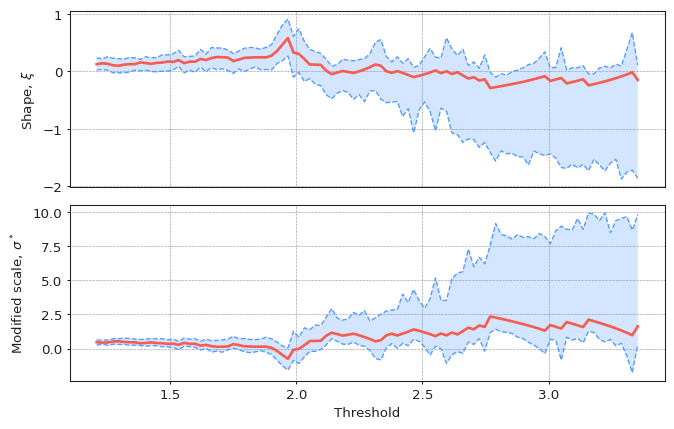

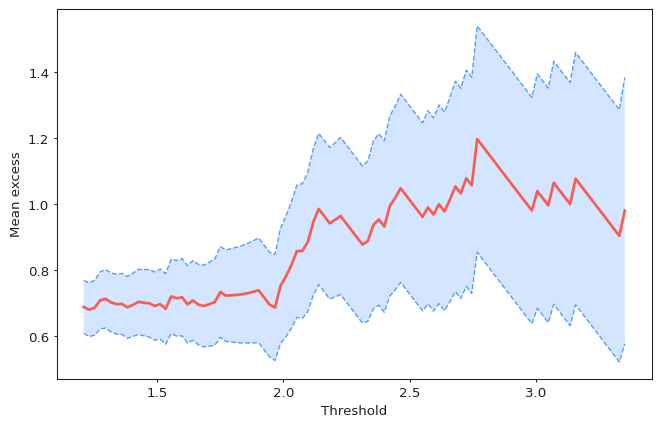

In [17]:
!pip install pyextremes
from pyextremes import plot_parameter_stability
from pyextremes import plot_mean_residual_life

plot_parameter_stability()
plot_mean_residual_life(x)


## Nicer Function for POT

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import genpareto

def pot_fit_var_es(
    x: pd.Series,
    alpha: float = 0.99,
    u_value: float | None = None,
    u_quantile: float | None = 0.95,
):
    """
    POT (GPD) fit + EVT VaR/ES for right tail of x (extreme losses).

    Parameters
    ----------
    x : pd.Series
        Standardized losses (right tail = extreme losses), e.g. x = (-std_resid.dropna()).
    alpha : float
        Target tail probability level for VaR/ES (e.g. 0.99).
    u_value : float or None
        Threshold as an absolute value (e.g. 2.2). If given, overrides u_quantile.
    u_quantile : float or None
        Threshold as empirical quantile (e.g. 0.95). Used if u_value is None.
    """
    x = pd.Series(x).dropna().astype(float)

    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1).")

    # --- choose threshold u ---
    if u_value is not None:
        u = float(u_value)
        # empirical quantile position of this u
        q_u = float((x <= u).mean())
    else:
        if u_quantile is None:
            raise ValueError("Provide either u_value or u_quantile.")
        if not (0 < u_quantile < 1):
            raise ValueError("u_quantile must be in (0, 1).")
        q_u = float(u_quantile)
        u = float(np.quantile(x, q_u))

    # --- exceedances and excesses ---
    exceed = x[x > u]
    excesses = (exceed - u).values
    n = len(x)
    nu = len(excesses)
    p_u = nu / n

    if nu < 10:
        raise RuntimeError(f"Too few exceedances ({nu}) for stable GPD fit. Consider lowering threshold.")

    # --- fit GPD to excesses Y = X-u | X>u, loc fixed at 0 ---
    xi_hat, loc_hat, sigma_hat = genpareto.fit(excesses, floc=0)

    # --- EVT VaR/ES on the standardized-loss scale X ---
    # Only valid for alpha > 1 - p_u (i.e., deeper into tail than threshold region)
    if alpha <= 1 - p_u:
        raise ValueError(
            f"alpha={alpha} is not in the extrapolation region for this threshold. "
            f"Need alpha > 1 - p_u = {1 - p_u:.4f}. "
            "Either increase alpha or lower the threshold."
        )

    # VaR formula (works also when xi ~ 0, but handle numerically)
    if abs(xi_hat) < 1e-8:
        # xi -> 0 limit: exponential tail
        var_alpha = u + sigma_hat * np.log(p_u / (1 - alpha))
    else:
        var_alpha = u + (sigma_hat / xi_hat) * ((( (1 - alpha) / p_u ) ** (-xi_hat)) - 1)

    # ES exists only if xi < 1
    if xi_hat >= 1:
        es_alpha = np.inf
    else:
        es_alpha = (var_alpha + sigma_hat - xi_hat * u) / (1 - xi_hat)

    # --- pretty print ---
    print("=== POT (GPD) fit on standardized losses X ===")
    print(f"n = {n}")
    print(f"Threshold u = {u:.4f}")
    print(f"Empirical quantile of u: q_u ≈ {q_u:.4f}")
    print(f"Exceedances nu = {nu}  ({p_u:.2%} of data), so 1 - p_u = {1 - p_u:.4f}")
    print()
    print("GPD parameters for excesses Y = X-u | X>u (SciPy genpareto):")
    print(f"  xi (shape)  = {xi_hat:.4f}")
    print(f"  sigma (scale)= {sigma_hat:.4f}")
    print()
    print(f"EVT VaR_X({alpha:.3f}) = {var_alpha:.4f}")
    print(f"EVT ES_X({alpha:.3f})  = {es_alpha:.4f}" if np.isfinite(es_alpha) else f"EVT ES_X({alpha:.3f})  = inf  (xi >= 1)")

    return {
        "u": u,
        "q_u": q_u,
        "p_u": p_u,
        "xi": xi_hat,
        "sigma": sigma_hat,
        "VaR": var_alpha,
        "ES": es_alpha,
        "nu": nu,
        "n": n
    }


res = pot_fit_var_es(x, alpha=0.99, u_value=2.2)      # threshold by value
# res = pot_fit_var_es(x, alpha=0.99, u_quantile=0.95)  # threshold by quantile

=== POT (GPD) fit on standardized losses X ===
n = 1546
Threshold u = 2.2000
Empirical quantile of u: q_u ≈ 0.9806
Exceedances nu = 30  (1.94% of data), so 1 - p_u = 0.9806

GPD parameters for excesses Y = X-u | X>u (SciPy genpareto):
  xi (shape)  = 0.0593
  sigma (scale)= 0.8715

EVT VaR_X(0.990) = 2.7892
EVT ES_X(0.990)  = 3.7528
